# Vehicle Detection using YOLOv8 with a Roboflow Dataset




**Connecting Google Colab to Google Drive**

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


**Unzip the zipped Dataset**

In [2]:

zip_path = '/content/gdrive/MyDrive/YOLO_Project/vehicles.v2i.yolov5pytorch.zip'

destination_path = '/content/dataset'

import zipfile
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(destination_path)

**Installing the Ultralytics Library**

In [3]:
!pip install ultralytics

**Preparing the Configuration File (paths)**

In [4]:
import yaml

file_path = '/content/dataset/data.yaml'

with open(file_path, 'r') as f:
    data_config = yaml.safe_load(f)

data_config['train'] = '/content/dataset/train/images'
data_config['val'] = '/content/dataset/valid/images'

with open('data_vehicle.yaml', 'w') as f:
    yaml.safe_dump(data_config, f)

print("Configuration file 'data_vehicle.yaml' prepared successfully!")

Configuration file 'data_vehicle.yaml' prepared successfully!


**Starting Training (shorten epochs for a short demonstration).**

In [5]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

results = model.train(
    data='data_vehicle.yaml',
    epochs=10,
    imgsz=640
)

Ultralytics 8.3.203 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data_vehicle.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretr

**Displaying the result plot and confusion matrix (like with matplotlib).**

In [6]:
# from IPython.display import Image, display

# Results
# display(Image(filename='/content/runs/detect/train/results.png'))

# Confusion Matrix
# display(Image(filename='/content/runs/detect/train/confusion_matrix.png'))

**Test: Running Detection (add/drag image to directory).**

In [9]:
from ultralytics import YOLO

model = YOLO('/content/runs/detect/train2/weights/best.pt')

results = model.predict(
    source='vehicle_test.jpg',
    conf=0.25,
    save=True
)


image 1/1 /content/vehicle_test.jpg: 448x640 21 cars, 1 small truck, 1 truck-m-, 38.8ms
Speed: 2.3ms preprocess, 38.8ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict


**Result.**

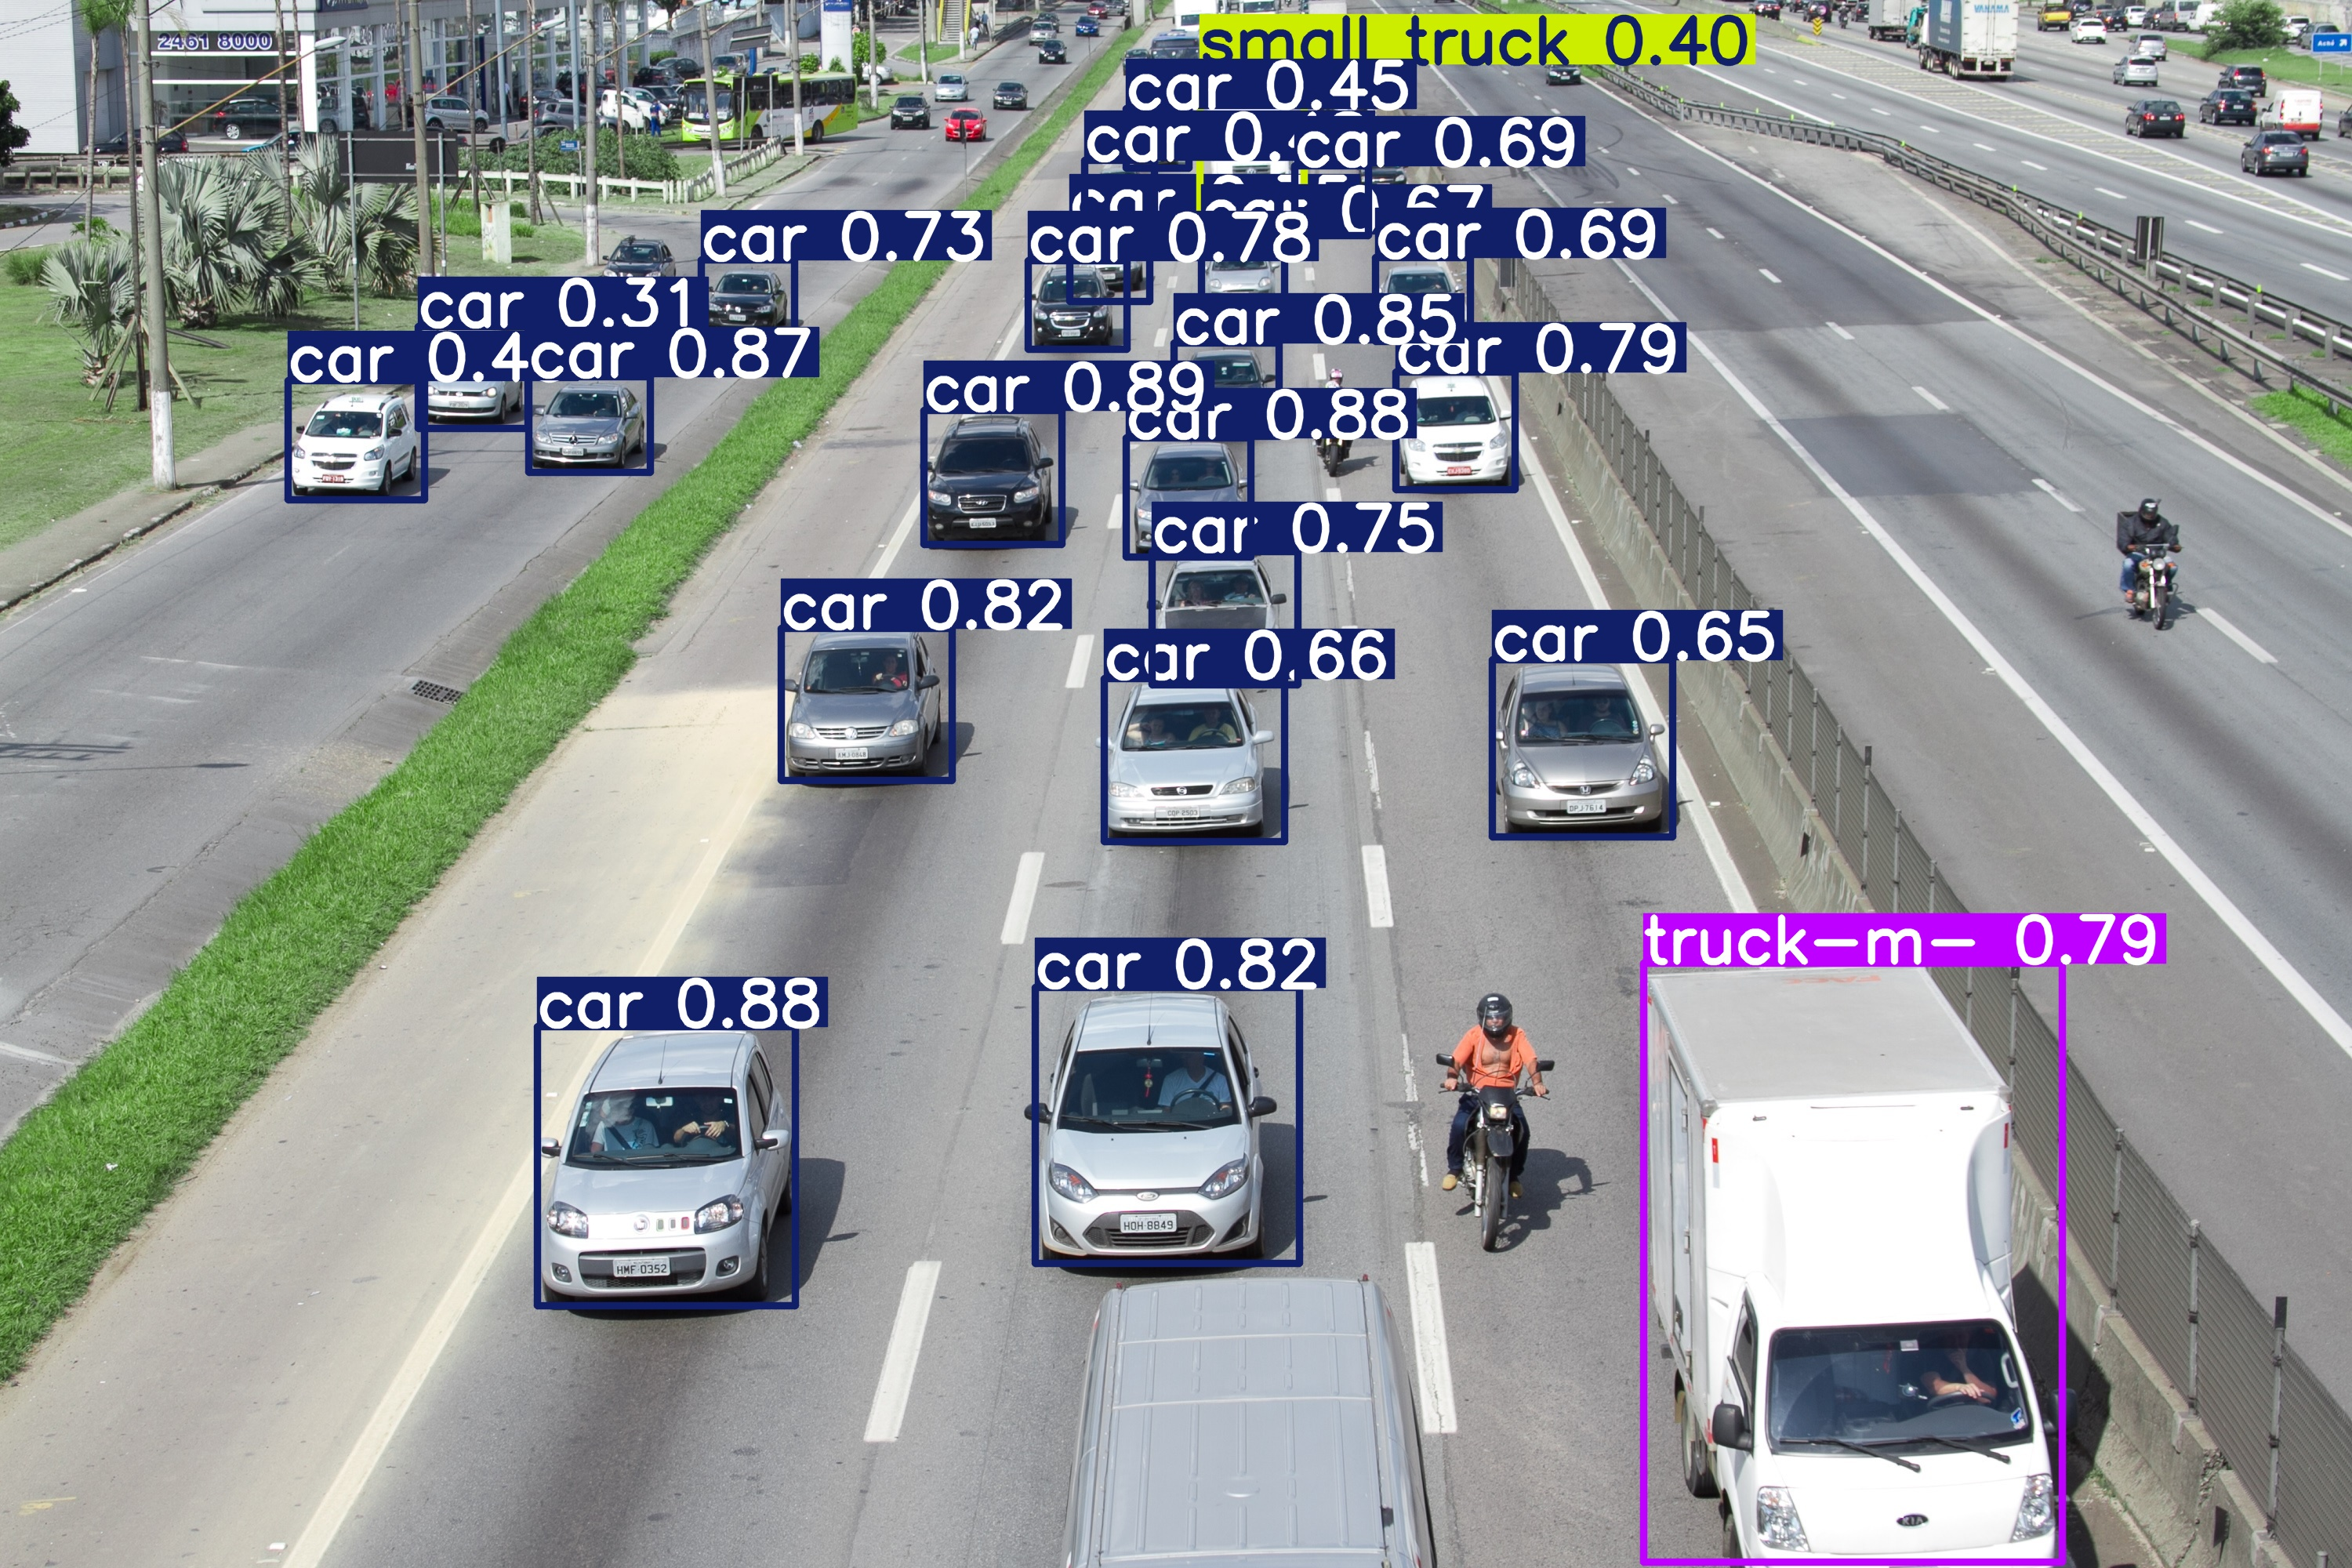

In [11]:
from IPython.display import Image, display

display(Image(filename='/content/runs/detect/predict/vehicle_test.jpg'))